<a href="https://colab.research.google.com/github/halimAhtasham/DeepLearning/blob/main/02_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction

## Phase 2: Exploratory Data Analysis (EDA)

### Objective
Explore the heart disease dataset, understand feature distributions,
identify missing values and duplicates, analyze the target variable,
and discover relationships between features.

## 1. Import Required Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Mount Google Drive

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
PROJECT_PATH = "/content/drive/MyDrive/Machine Learning/Projects/Heart Disease Prediction"
DATASET_PATH = PROJECT_PATH + "/Dataset"
IMAGE_PATH = PROJECT_PATH + "/Images"

##Load the Datasets

In [29]:
df = pd.read_csv(DATASET_PATH + "/heart.csv")

In [30]:
# first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2. Dataset Overview

In [31]:
# rows and columns count
df.shape

(1025, 14)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [33]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 3. Missing Values

In [34]:
# missing value in columns
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [35]:
# total number of missing values
df.isnull().sum().sum()

np.int64(0)

## 4. Duplicate Records

In [36]:
# how many duplicate rows exist.
df.duplicated().sum()

np.int64(723)

In [37]:
# which rows are duplicated
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


## 5. Target Variable Distribution

In [38]:
df["target"].value_counts()

,count
target,
1,526
0,499


In [39]:
df["target"].value_counts(normalize=True) * 100

,proportion
target,
1,51.317073
0,48.682927


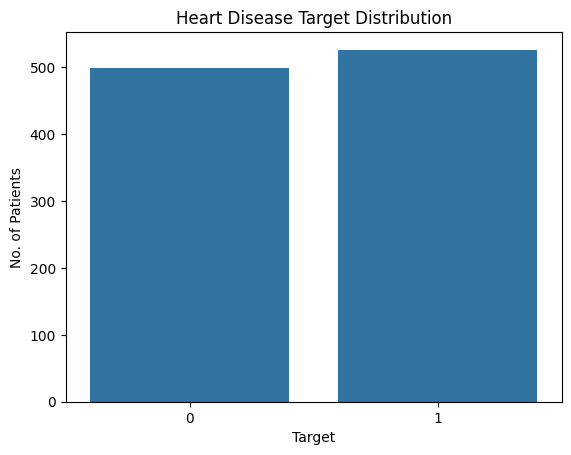

In [40]:
sns.countplot(data=df, x = "target")

plt.title("Heart Disease Target Distribution")
plt.xlabel("Target")
plt.ylabel("No. of Patients")

plt.show()

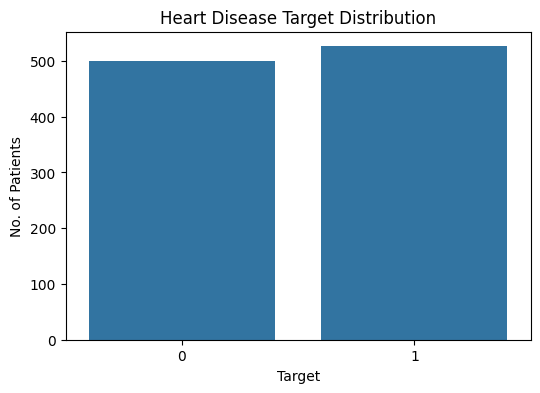

In [50]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="target")

plt.title("Heart Disease Target Distribution")
plt.xlabel("Target")
plt.ylabel("No. of Patients")

plt.savefig(
    IMAGE_PATH + "/target_distribution.png",
    bbox_inches="tight"
)

plt.show()

#Age Distribution

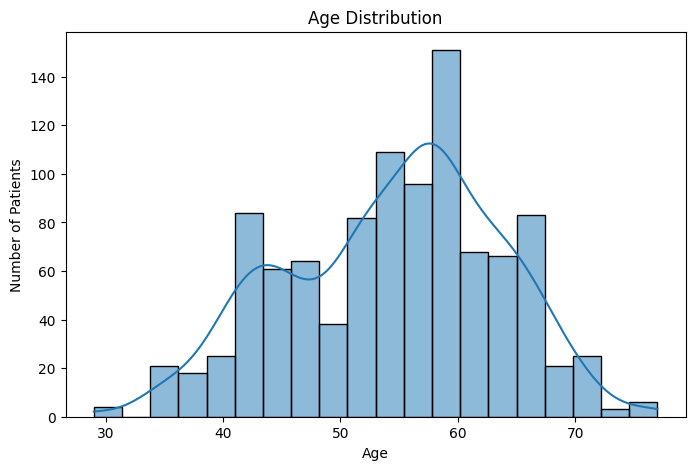

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="age", bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.savefig(
    IMAGE_PATH + "/age_distribution.png",
    bbox_inches="tight"
)

plt.show()

#Age vs Target

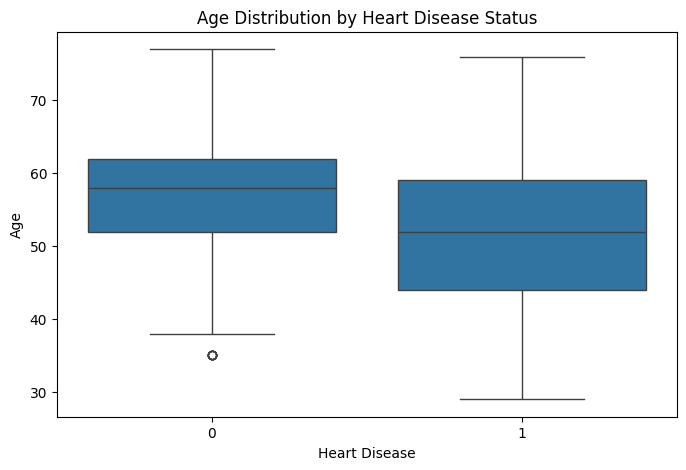

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="target", y="age")

plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Age")

plt.savefig(
    IMAGE_PATH + "/age_distribution_vs_target.png",
    bbox_inches="tight"
)

plt.show()

#Gender Distribution

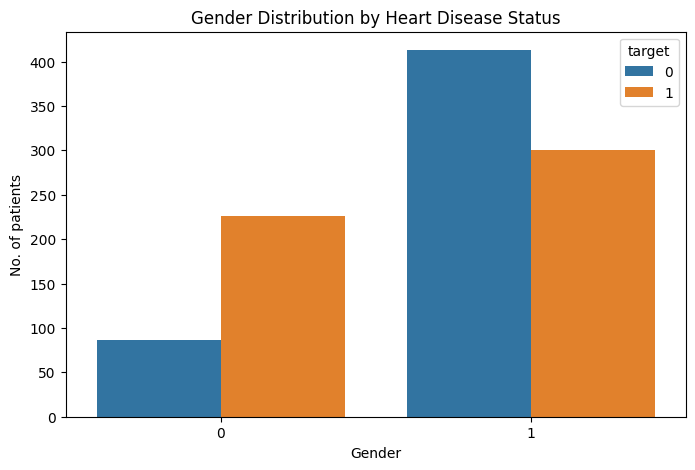

In [55]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="sex", hue="target")

plt.title("Gender Distribution by Heart Disease Status")
plt.xlabel("Gender")
plt.ylabel("No. of patients")

plt.savefig(
    IMAGE_PATH + "/gender_distribution.png",
    bbox_inches="tight"
)

#Feature Correlation



In [45]:
correlation = df.corr()

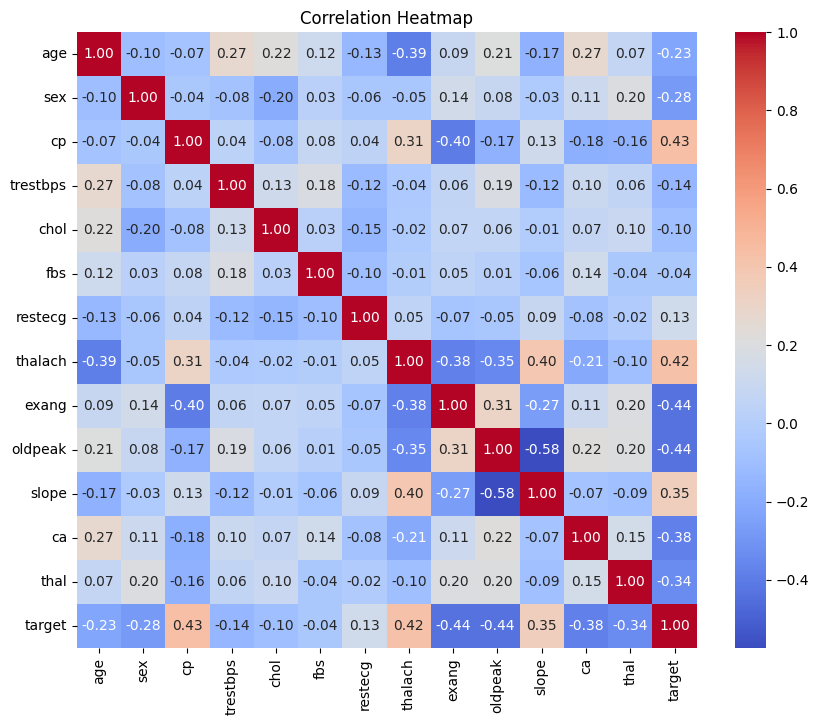

In [56]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.savefig(
    IMAGE_PATH + "/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.title("Correlation Heatmap")
plt.show()

In [47]:
target_correlation = correlation["target"].sort_values(ascending=False)

In [48]:
target_correlation

,target
target,1.000000
cp,0.434854
thalach,0.422895
slope,0.345512
restecg,0.134468
fbs,-0.041164
chol,-0.099966
trestbps,-0.138772
age,-0.229324
sex,-0.279501


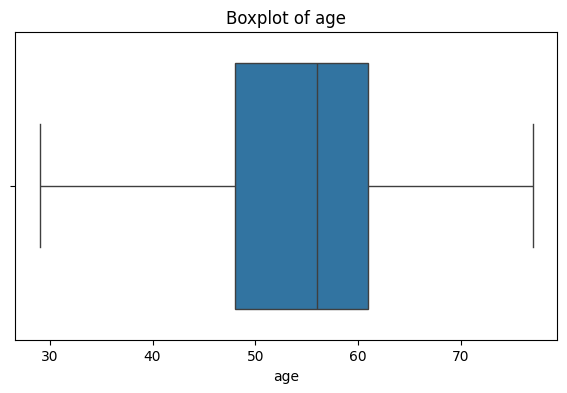

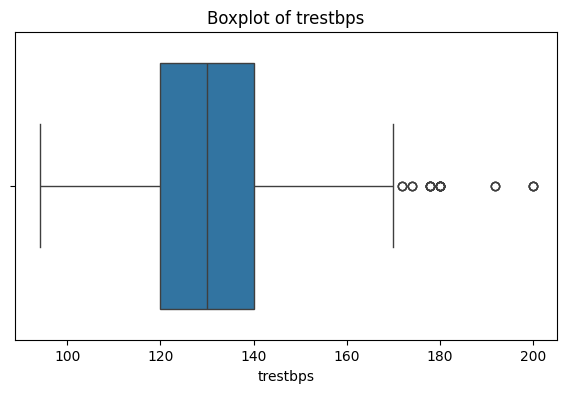

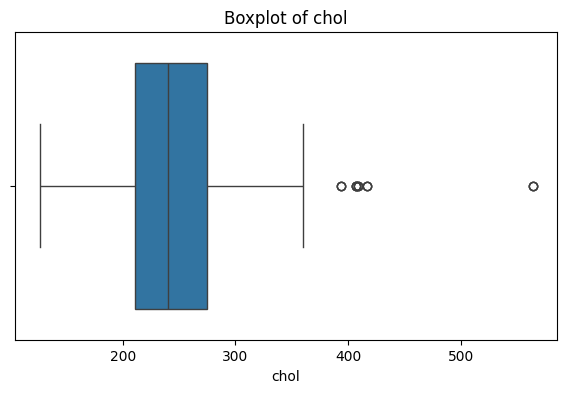

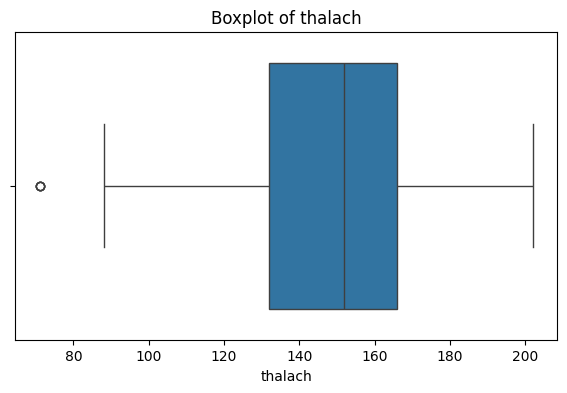

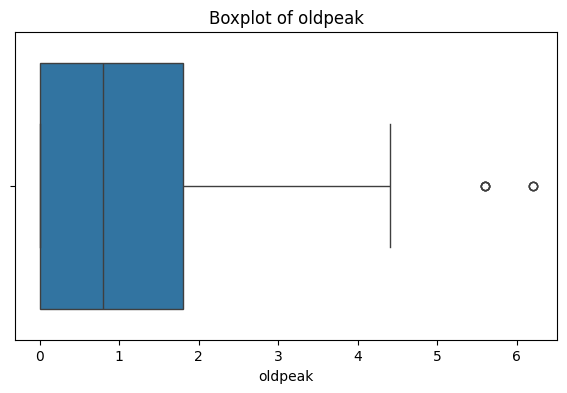

In [49]:
features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

for feature in features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(data=df, x=feature)

    plt.title(f"Boxplot of {feature}")
    plt.show()

# EDA Findings

## Dataset Structure

- The dataset contains 1025 records and 14 columns.
- There are 13 input features and one target variable.
- All columns contain numerical values.

## Missing Values

- No missing values were detected.

## Duplicate Records

- 723 duplicate rows were detected.
- This is a substantial proportion of the dataset.
- Further investigation is required before deciding whether to remove them.

## Target Distribution

- 526 records belong to class 1.
- 499 records belong to class 0.
- The target distribution is relatively balanced.

## Correlation

- `cp`, `thalach`, `slope` show positive correlation with the target.
- `oldpeak`, `exang`, `ca`, and `thal` show negative correlation with the target.
- Correlation alone will not be used to determine feature importance.

In [60]:
# Number of unique rows
df.drop_duplicates().shape

(302, 14)

In [59]:
# Number of unique patients/records
df.nunique()

,0
age,41
sex,2
cp,4
trestbps,49
chol,152
fbs,2
restecg,3
thalach,91
exang,2
oldpeak,40


In [61]:
# How many times does each row appear?
df.value_counts().head(20)

age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
38   1    2   138       175   0    1        173      0      0.0      2      4   2     1         8
40   1    0   152       223   0    1        181      0      0.0      2      0   3     0         4
              110       167   0    0        114      1      2.0      1      0   3     0         4
41   1    1   120       157   0    1        182      0      0.0      2      0   2     1         4
71   0    0   112       149   0    1        125      0      1.6      1      0   2     1         4
          2   110       265   1    0        130      0      0.0      2      1   2     1         4
39   1    0   118       219   0    1        140      0      1.2      1      0   3     0         4
64   1    0   120       246   0    0        96       1      2.2      0      1   2     0         4
          2   125       309   0    1        131      1      1.8      1      0   3     0         4
              140       335   0    1        158      0      0.0      2      0   2     0         4
          3   170       227   0    0        155      0      0.6      1      0   3     1         4
65   0    0   150       225   0    0        114      0      1.0      1      3   3     0         4
43   1    0   120       177   0    0        120      1      2.5      1      0   3     0         4
66   0    2   146       278   0    0        152      0      0.0      1      1   2     1         4
     1    0   112       212   0    0        132      1      0.1      2      1   2     0         4
              160       228   0    0        138      0      2.3      2      0   1     1         4
65   1    0   135       254   0    0        127      0      2.8      1      1   3     0         4
          3   138       282   1    0        174      0      1.4      1      1   2     0         4
29   1    1   130       204   0    0        202      0      0.0      2      0   2     1         4
62   1    1   120       281   0    0        103      0      1.4      1      1   3     0         4
Name: count, dtype: int64

In [62]:
df.value_counts().value_counts().sort_index()

,count
count,
3,187
4,114
8,1


In [64]:
df_clean = df.drop_duplicates().copy()

In [65]:
df_clean.shape

(302, 14)

In [66]:
df_clean.duplicated().sum()

np.int64(0)

### Duplicate Analysis

The dataset contains 1,025 records, but only 302 unique complete records.
Every unique record appears at least three times, with most appearing
three or four times and one record appearing eight times.

Because exact duplicate records can appear in both training and testing
sets and potentially lead to overly optimistic evaluation results, exact
duplicates will be removed before model development.

The original dataset will remain unchanged, and a separate cleaned
DataFrame will be used for subsequent analysis.

In [67]:
df_clean = df.drop_duplicates().copy()

print("Original dataset:", df.shape)
print("After removing duplicates:", df_clean.shape)

print("\nOriginal target distribution:")
print(df["target"].value_counts())

print("\nCleaned target distribution:")
print(df_clean["target"].value_counts())

print("\nCleaned target percentage:")
print(df_clean["target"].value_counts(normalize=True) * 100)

Original dataset: (1025, 14)
After removing duplicates: (302, 14)

Original target distribution:
target
1    526
0    499
Name: count, dtype: int64

Cleaned target distribution:
target
1    164
0    138
Name: count, dtype: int64

Cleaned target percentage:
target
1    54.304636
0    45.695364
Name: proportion, dtype: float64
